#Demonstration of how CUDA enables GPU computation
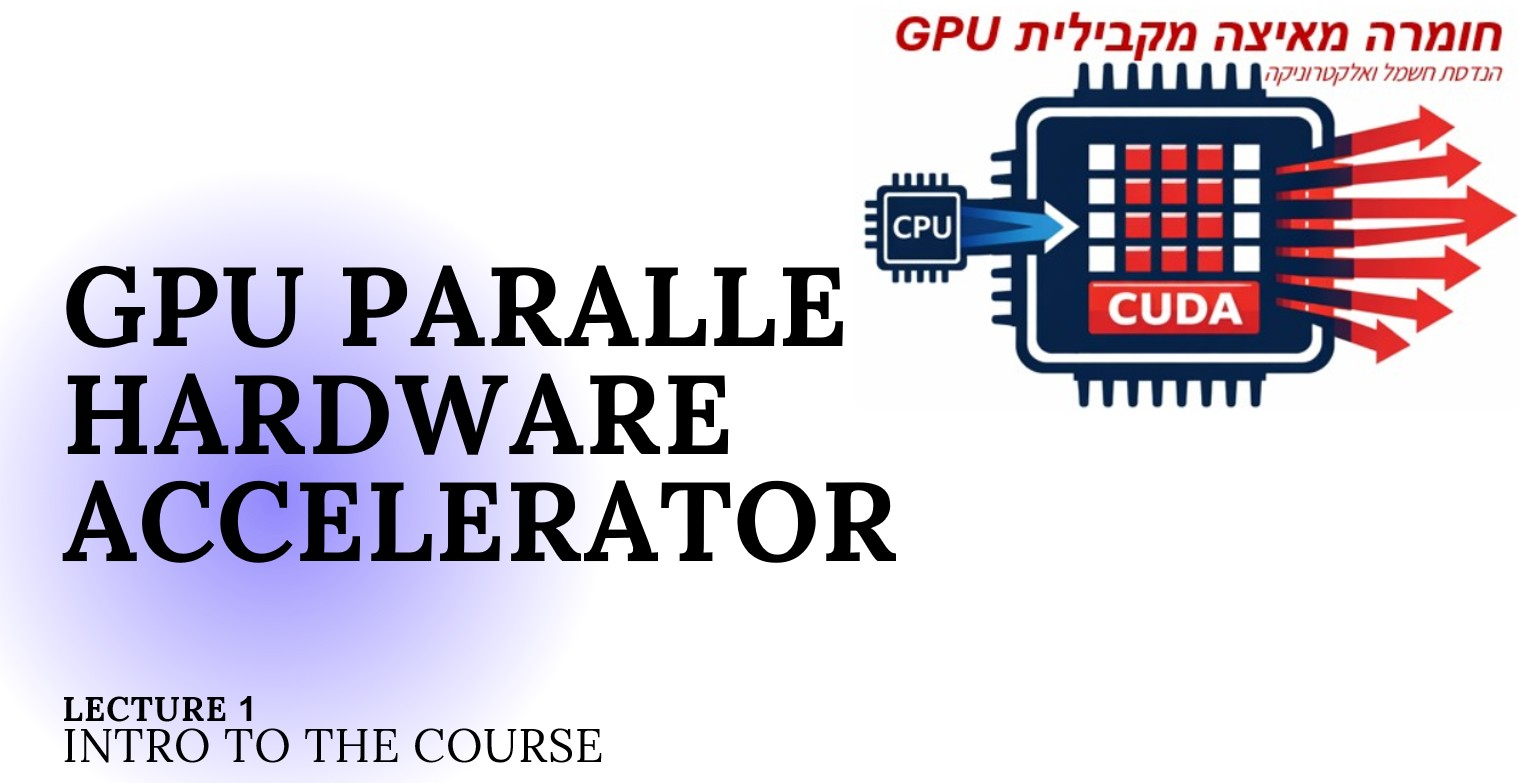




```
# This is formatted as code
```Installing nvcc4jupyter in Google Colab gives you the ability to write and run CUDA C/C++ code directly inside notebook cells — just like you run Python.

 ### Installing nvcc4jupyter

 First, you need to install the nvcc4jupyter plugin in your Colab notebook. This can be done by running

<a href="https://colab.research.google.com/github/gittimos/cuda-colab/blob/main/CUDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
pip install nvcc4jupyter


### Loading the Extension
After installation, load the extension by running the following cell:
Your CUDA code (or compiled files) are being stored in a temporary directory inside the Colab environment  (inside  remote machine)

In [9]:
%load_ext nvcc4jupyter

The nvcc4jupyter extension is already loaded. To reload it, use:
  %reload_ext nvcc4jupyter


### Writing CUDA Code

## Example number 1 : You're ready to write your CUDA code. Use the %%cuda magic command at the beginning of a cell to indicate that the following code is CUDA C++ code:

In [29]:
%%cuda
#include <stdio.h>

__global__ void hello(){
    printf("Hello from block: %u, thread: %u\n", blockIdx.x, threadIdx.x);
}

int main(){
    hello<<<2, 2>>>();
    cudaDeviceSynchronize();
}

Hello from block: 1, thread: 0
Hello from block: 1, thread: 1
Hello from block: 0, thread: 0
Hello from block: 0, thread: 1



Example #2
## Adds two vectors (arrays) using CPU and GPU, measures time, and compares Performance **bold text**

In [38]:
%%writefile cuda_vs_cpu.cu
#include <iostream>
#include <vector>
#include <chrono>
#include <cuda_runtime.h>

__global__ void vecAdd(const float* A, const float* B, float* C, int N) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i < N) {
        C[i] = A[i] + B[i];
    }
}

int main() {
    std::vector<int> sizes = {
        10000,
        100000,
        1000000,
        5000000,
        10000000
    };

    std::cout << "N,CPU_ms,GPU_ms\n";

    for (int N : sizes) {
        std::vector<float> h_A(N, 1.0f);
        std::vector<float> h_B(N, 2.0f);
        std::vector<float> h_C_cpu(N, 0.0f);
        std::vector<float> h_C_gpu(N, 0.0f);

        float *d_A, *d_B, *d_C;
        cudaMalloc(&d_A, N * sizeof(float));
        cudaMalloc(&d_B, N * sizeof(float));
        cudaMalloc(&d_C, N * sizeof(float));

        cudaMemcpy(d_A, h_A.data(), N * sizeof(float), cudaMemcpyHostToDevice);
        cudaMemcpy(d_B, h_B.data(), N * sizeof(float), cudaMemcpyHostToDevice);

        // CPU timing
        auto cpu_start = std::chrono::high_resolution_clock::now();
        for (int i = 0; i < N; i++) {
            h_C_cpu[i] = h_A[i] + h_B[i];
        }
        auto cpu_end = std::chrono::high_resolution_clock::now();
        double cpu_ms = std::chrono::duration<double, std::milli>(cpu_end - cpu_start).count();

        // GPU timing
        cudaEvent_t start, stop;
        cudaEventCreate(&start);
        cudaEventCreate(&stop);

        int threadsPerBlock = 256;
        int blocksPerGrid = (N + threadsPerBlock - 1) / threadsPerBlock;

        cudaEventRecord(start);
        vecAdd<<<blocksPerGrid, threadsPerBlock>>>(d_A, d_B, d_C, N);
        cudaEventRecord(stop);
        cudaEventSynchronize(stop);

        float gpu_ms = 0.0f;
        cudaEventElapsedTime(&gpu_ms, start, stop);

        cudaMemcpy(h_C_gpu.data(), d_C, N * sizeof(float), cudaMemcpyDeviceToHost);

        // very small correctness check
        bool ok = true;
        for (int i = 0; i < 5 && i < N; i++) {
            if (h_C_gpu[i] != 3.0f) ok = false;
        }

        if (!ok) {
            std::cerr << "Mismatch detected at N=" << N << std::endl;
        }

        std::cout << N << "," << cpu_ms << "," << gpu_ms << "\n";

        cudaEventDestroy(start);
        cudaEventDestroy(stop);
        cudaFree(d_A);
        cudaFree(d_B);
        cudaFree(d_C);
    }

    return 0;
}

Overwriting cuda_vs_cpu.cu


In [39]:
!nvcc cuda_vs_cpu.cu -O2 -o cuda_vs_cpu
!./cuda_vs_cpu > results.csv
!cat results.csv

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
N,CPU_ms,GPU_ms
10000,0.007345,0.169344
100000,0.066695,0.015968
1000000,0.904848,0.054944
5000000,5.51442,0.24576
10000000,10.639,0.473216


In [40]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("results.csv")
df

,N,CPU_ms,GPU_ms
0,10000,0.007345,0.169344
1,100000,0.066695,0.015968
2,1000000,0.904848,0.054944
3,5000000,5.514420,0.245760
4,10000000,10.639000,0.473216


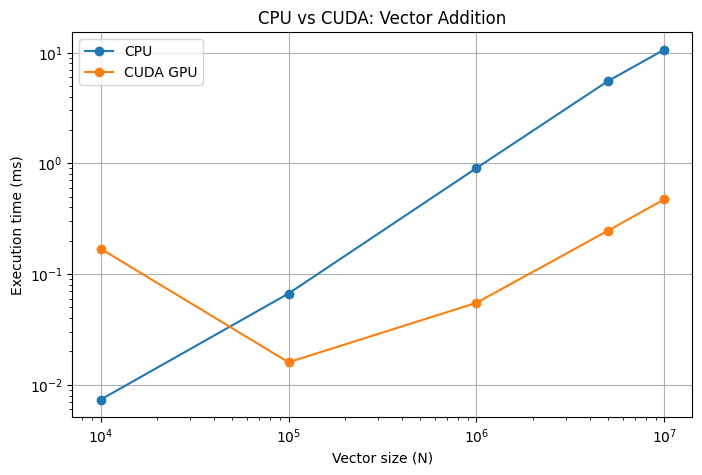

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(df["N"], df["CPU_ms"], marker='o', label="CPU")
plt.plot(df["N"], df["GPU_ms"], marker='o', label="CUDA GPU")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Vector size (N)")
plt.ylabel("Execution time (ms)")
plt.title("CPU vs CUDA: Vector Addition")
plt.legend()
plt.grid(True)
plt.show()